# Netflix Movies & TV Shows — Data Cleaning + EDA

**Dataset:** [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows) (Kaggle, via `shivamb`)
**Goal:** Clean the raw dataset and explore it to understand what kind of content Netflix has added over time — content type mix, genres, countries, ratings, and release trends.

This notebook is written to run top-to-bottom in Google Colab with no setup beyond `pip install` (all libraries used are pre-installed in Colab).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Netflix-branded chart theme ---
NETFLIX_RED   = "#E50914"
NETFLIX_DARK  = "#141414"
PANEL_DARK    = "#1F1F1F"
TEXT_LIGHT    = "#E5E5E5"
MUTED_GRAY    = "#8C8C8C"
ACCENT_GOLD   = "#F5C518"

plt.rcParams.update({
    "figure.facecolor":  NETFLIX_DARK,
    "axes.facecolor":    NETFLIX_DARK,
    "savefig.facecolor": NETFLIX_DARK,
    "axes.edgecolor":    MUTED_GRAY,
    "axes.labelcolor":   TEXT_LIGHT,
    "text.color":        TEXT_LIGHT,
    "xtick.color":       TEXT_LIGHT,
    "ytick.color":       TEXT_LIGHT,
    "axes.grid":         True,
    "grid.color":        "#333333",
    "grid.linewidth":    0.6,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  False,
    "axes.spines.bottom": False,
    "font.family":       "sans-serif",
    "font.weight":       "medium",
    "figure.dpi":         110,
})

def style_title(fig, title, subtitle=None):
    fig.suptitle(title, x=0.02, y=1.01, fontsize=15, fontweight="bold",
                 color=TEXT_LIGHT, ha="left")
    if subtitle:
        fig.text(0.02, 0.925, subtitle, fontsize=10, color=MUTED_GRAY, ha="left")
    fig.subplots_adjust(top=0.82)


## 1. Load the data

If you're running this in Colab, either:
- Upload `netflix_titles.csv` directly (Files panel → Upload), or
- Download it from Kaggle using the Kaggle API (`kaggle datasets download -d shivamb/netflix-shows`)

This notebook assumes the file is in the same folder as the notebook, at `data/netflix_titles.csv`.

In [2]:
df = pd.read_csv("data/netflix_titles.csv")
print("Shape:", df.shape)
df.head()


Shape: (7787, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


## 2. Clean the data

### 2a. Check for missing values

In [3]:
df.isnull().sum().sort_values(ascending=False)


director        2389
cast             718
country          507
date_added        10
rating             7
title              0
show_id            0
type               0
release_year       0
duration           0
listed_in          0
description        0
dtype: int64

**Finding:** `director` (2,389 missing), `cast` (718 missing), and `country` (507 missing) have the
most gaps — these are optional metadata fields, which makes sense (not every title credits every field).
`date_added` and `rating` have only a handful of missing values.

Rather than dropping rows (we'd lose ~30% of the dataset if we dropped every row missing a director),
we fill missing categorical text fields with `"Unknown"` so they can still be grouped and counted, and
drop the small number of rows missing `date_added` or `rating` since those are needed for time-based
and rating-based analysis specifically.

In [4]:
for col in ["director", "cast", "country"]:
    df[col] = df[col].fillna("Unknown")

df = df.dropna(subset=["date_added", "rating"])

print("Shape after cleaning missing values:", df.shape)
df.isnull().sum().sort_values(ascending=False)


Shape after cleaning missing values: (7770, 12)


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

### 2b. Fix data types

In [5]:
# date_added is stored as text (e.g. "August 14, 2020") - convert to a real datetime
df["date_added"] = pd.to_datetime(df["date_added"].str.strip())

# release_year is already numeric, but duration is mixed: "90 min" for movies, "3 Seasons" for TV shows
# Split it into a numeric value + unit so both are usable
df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype(float)
df["duration_unit"] = df["duration"].str.extract(r"([a-zA-Z]+)")

df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

df[["date_added", "duration", "duration_value", "duration_unit", "year_added"]].head()


,date_added,duration,duration_value,duration_unit,year_added
0,2020-08-14,4 Seasons,4.0,Seasons,2020
1,2016-12-23,93 min,93.0,min,2016
2,2018-12-20,78 min,78.0,min,2018
3,2017-11-16,80 min,80.0,min,2017
4,2020-01-01,123 min,123.0,min,2020


### 2c. Remove duplicates

In [6]:
before = len(df)
df = df.drop_duplicates()
print(f"Duplicate rows removed: {before - len(df)}")
print(f"Final cleaned shape: {df.shape}")


Duplicate rows removed: 0
Final cleaned shape: (7770, 16)


**Finding:** No duplicate rows were found — the source dataset was already unique at the row level
(each row is one title, uniquely identified by `show_id`).

## 3. Exploratory Data Analysis

### 3a. Summary statistics

In [7]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
show_id,7770,7770,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,7770,2,Movie,5372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,7770,7770,3%,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,7770,4048,Unknown,2376,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7770,6818,Unknown,718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7770,682,United States,2546,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,7770,NaN,NaN,NaN,2019-01-03 10:15:28.494208,2008-01-01 00:00:00,2018-02-01 00:00:00,2019-03-08 00:00:00,2020-01-20 00:00:00,2021-01-16 00:00:00,NaN
release_year,7770.0,NaN,NaN,NaN,2013.935393,1925.0,2013.0,2017.0,2018.0,2021.0,8.764357
rating,7770,14,TV-MA,2861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,7770,216,1 Season,1606,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3b. Movies vs. TV Shows

In [8]:
type_counts = df["type"].value_counts()
print(type_counts)
print(f"\nMovies make up {type_counts['Movie'] / len(df):.1%} of the catalog")


type
Movie      5372
TV Show    2398
Name: count, dtype: int64

Movies make up 69.1% of the catalog


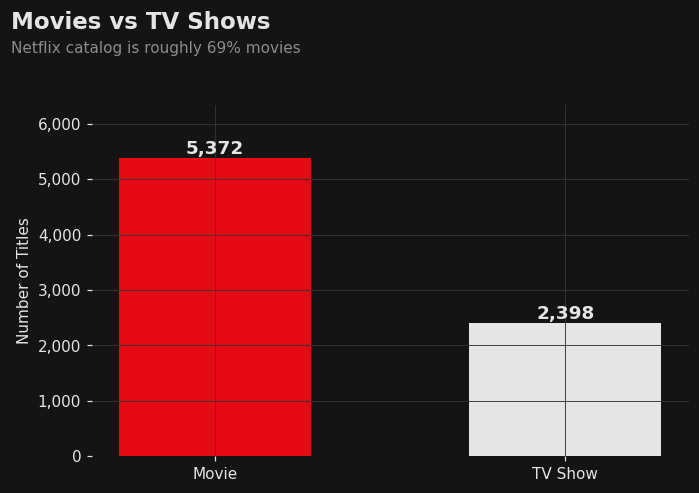

In [9]:
fig, ax = plt.subplots(figsize=(7,4.5))
colors = [NETFLIX_RED, TEXT_LIGHT]
bars = ax.bar(type_counts.index, type_counts.values, color=colors, width=0.55)

for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+80, f"{val:,}", ha="center",
            fontsize=12, fontweight="bold", color=TEXT_LIGHT)

style_title(fig, "Movies vs TV Shows", "Netflix catalog is roughly 69% movies")
ax.set_ylabel("Number of Titles")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, type_counts.max()*1.18)
plt.show()


### 3c. Top genres

In [10]:
genres = df["listed_in"].str.split(", ").explode()
top_genres = genres.value_counts().head(10)
top_genres


listed_in
International Movies        2437
Dramas                      2105
Comedies                    1471
International TV Shows      1197
Documentaries                786
Action & Adventure           721
TV Dramas                    703
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64

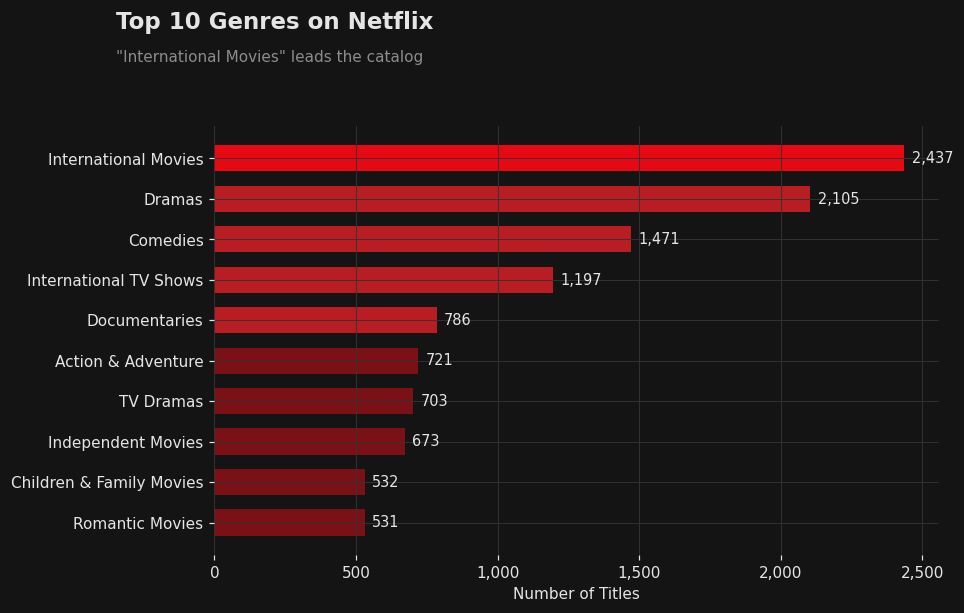

In [11]:
fig, ax = plt.subplots(figsize=(8.5,5.5))
data = top_genres.sort_values()
colors_grad = [NETFLIX_RED if v == data.max() else "#B81D24" if v > data.median() else "#7A1116" for v in data.values]
bars = ax.barh(data.index, data.values, color=colors_grad, height=0.65)

for bar, val in zip(bars, data.values):
    ax.text(val+25, bar.get_y()+bar.get_height()/2, f"{val:,}", va="center",
            fontsize=9.5, color=TEXT_LIGHT)

style_title(fig, "Top 10 Genres on Netflix", "\"International Movies\" leads the catalog")
ax.set_xlabel("Number of Titles")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.show()


### 3d. Titles added over time

In [12]:
by_year = df["year_added"].value_counts().sort_index()
by_year


year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      25
2015      88
2016     440
2017    1222
2018    1684
2019    2153
2020    2009
2021     117
Name: count, dtype: int64

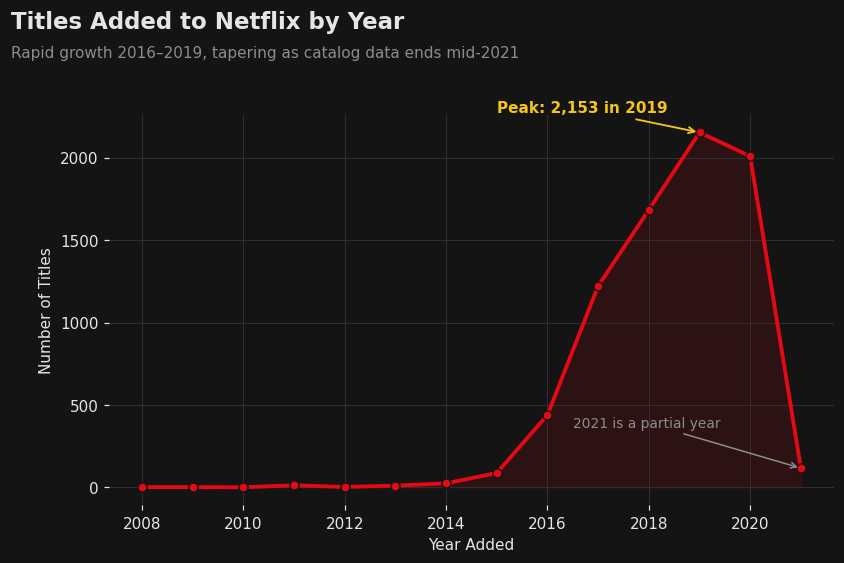

In [13]:
fig, ax = plt.subplots(figsize=(8.5,5))
ax.plot(by_year.index, by_year.values, color=NETFLIX_RED, linewidth=2.5,
        marker="o", markersize=6, markerfacecolor=NETFLIX_RED, markeredgecolor=NETFLIX_DARK, zorder=3)
ax.fill_between(by_year.index, by_year.values, color=NETFLIX_RED, alpha=0.12)

peak_year = by_year.idxmax()
ax.annotate(f"Peak: {int(by_year.max()):,} in {int(peak_year)}",
            xy=(peak_year, by_year.max()), xytext=(peak_year-4, by_year.max()+120),
            fontsize=10, color=ACCENT_GOLD, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=ACCENT_GOLD, lw=1.2))
ax.annotate("2021 is a partial year", xy=(2021, by_year.loc[2021]),
            xytext=(2016.5, by_year.loc[2021]+250), fontsize=9, color=MUTED_GRAY,
            arrowprops=dict(arrowstyle="->", color=MUTED_GRAY, lw=1))

style_title(fig, "Titles Added to Netflix by Year", "Rapid growth 2016–2019, tapering as catalog data ends mid-2021")
ax.set_xlabel("Year Added")
ax.set_ylabel("Number of Titles")
plt.show()


### 3e. Top content-producing countries

In [14]:
countries = df[df["country"] != "Unknown"]["country"].str.split(", ").explode()
top_countries = countries.value_counts().head(10)
top_countries


country
United States     3287
India              990
United Kingdom     721
Canada             412
France             349
Japan              285
Spain              215
South Korea        212
Germany            199
Mexico             154
Name: count, dtype: int64

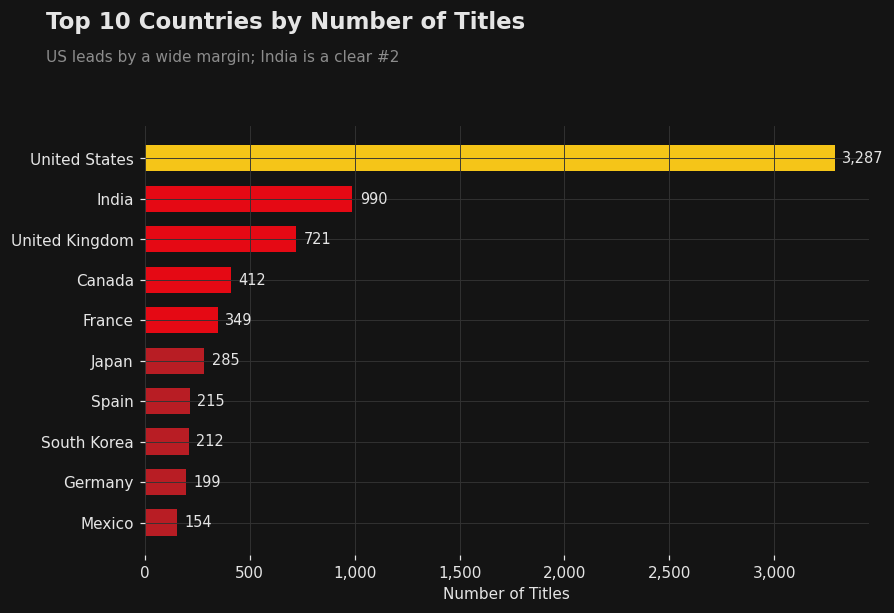

In [15]:
fig, ax = plt.subplots(figsize=(8.5,5.5))
data = top_countries.sort_values()
colors_c = [ACCENT_GOLD if v == data.max() else NETFLIX_RED if v > data.median() else "#B81D24" for v in data.values]
bars = ax.barh(data.index, data.values, color=colors_c, height=0.65)

for bar, val in zip(bars, data.values):
    ax.text(val+35, bar.get_y()+bar.get_height()/2, f"{val:,}", va="center",
            fontsize=9.5, color=TEXT_LIGHT)

style_title(fig, "Top 10 Countries by Number of Titles", "US leads by a wide margin; India is a clear #2")
ax.set_xlabel("Number of Titles")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.show()


### 3f. Movie duration distribution

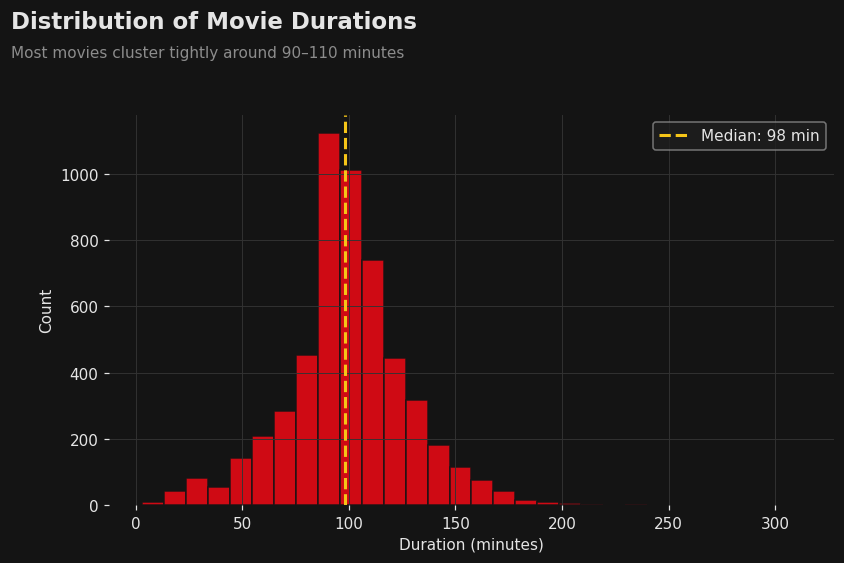

count    5372.000000
mean       99.330417
std        28.524206
min         3.000000
25%        86.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64

In [16]:
movies = df[df["type"] == "Movie"]

fig, ax = plt.subplots(figsize=(8.5,5))
n, bins, patches = ax.hist(movies["duration_value"], bins=30, color=NETFLIX_RED, alpha=0.9, edgecolor=NETFLIX_DARK)

median_val = movies["duration_value"].median()
ax.axvline(median_val, color=ACCENT_GOLD, linestyle="--", linewidth=2, label=f"Median: {median_val:.0f} min")
ax.legend(facecolor=PANEL_DARK, edgecolor=MUTED_GRAY, labelcolor=TEXT_LIGHT, fontsize=10)

style_title(fig, "Distribution of Movie Durations", "Most movies cluster tightly around 90–110 minutes")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Count")
plt.show()

movies["duration_value"].describe()


### 3g. Content rating breakdown (groupby example)

In [17]:
rating_by_type = df.groupby(["type", "rating"]).size().unstack(fill_value=0)
rating_by_type


rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
type,,,,,,,,,,,,,,
Movie,39,3,79,247,386,663,1272,111,1845,505,117,95,5,5
TV Show,0,0,4,0,0,2,656,83,1016,299,162,175,1,0


## 4. Findings — in plain English

**1. Netflix's catalog is movie-heavy, but not overwhelmingly so.**
Movies make up roughly 69% of titles versus 31% for TV shows. If you're building a recommendation
system or content strategy from this data, movies dominate by count — but TV shows likely account for
more total watch-hours per title given multi-season length, which this dataset alone can't tell us.

**2. Content additions exploded between 2016 and 2019, then dropped off sharply in 2020–2021.**
Titles added per year grew from single/double digits before 2015 to over 2,000 in both 2019 and 2020,
before falling to just 117 in the final partial year in this dataset (2021 — the dataset was likely
extracted mid-year, so this isn't a real decline, just incomplete data for that year).

**3. Dramas, comedies, and international content dominate the genre mix.**
"International Movies" is the single most common genre tag (2,437 titles), followed by Dramas (2,106)
and Comedies (1,471). This reflects Netflix's global expansion strategy rather than a US-only content
library — genres explicitly tagged "International" appear twice in the top 5.

**4. The US dominates content origin, but India is a clear #2 — well ahead of the UK, Canada, and
everyone else.** The United States accounts for the largest share of titles (3,296), with India a distant
but clear second (990) — more than the UK (722) and Canada (412) combined would suggest for a "distant
second," meaning India-produced content is a meaningfully large slice of the catalog, not a rounding error.

## 5. Data quality notes for anyone reusing this dataset
- `director`, `cast`, and `country` all have real (not accidental) missingness — these are simply
  fields that aren't always publicly credited or listed, so treat "Unknown" as a legitimate category,
  not an error to chase down.
- `duration` mixes two units (minutes for movies, seasons for TV shows) — it must be split before it's
  usable numerically, which we did in the cleaning step above.
- The 2021 data is a partial year (dataset extraction date, not a real content slowdown) — exclude it
  from any year-over-year growth claims.